# Разпределение на задачи

Отвори в Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)]({{< var colabPrefix >}}06-01-Job-Assignment.ipynb)

Агенция за кредитен рейтинг е разпределила трима служители по проект за оценка на структурирани финансови продукти. Проектът има три основни подзадачи:

- Разработване на статистически модели (S)
- Проучване на финансови продукти, литература и пазарна информация (R)
- Разработване на качествени модели (Q)

Всеки сътрудник трябва да поеме една подзадача. Сътрудниците имат различни умения и предпочитания, които влияят върху тяхната ефективност в различните подзадачи. Тяхната ефективност е дадена в @tbl-efficiency-scores (по-голяма стойност означава по-висока ефективност). Същата информация е представена и визуално като
двуделен граф във @fig-graph-efficiency-scores.

In [1]:
%pip install gurobipy

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

dt = pd.DataFrame({
    'S': [53, 27, 13],
    'R': [80, 47, 67],
    'Q': [53, 73, 47]
}, index=['Boyko', 'Peter', 'Radi'])

dt.to_excel("./excel/Job-Allocation.xlsx", sheet_name="Scores")

/home/boyko/opt2026/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
#| label: tbl-efficiency-scores
#| tbl-cap: "Ефективност на сътрудници по задачи."

dt

,S,R,Q
Boyko,53,80,53
Peter,27,47,73
Radi,13,67,47


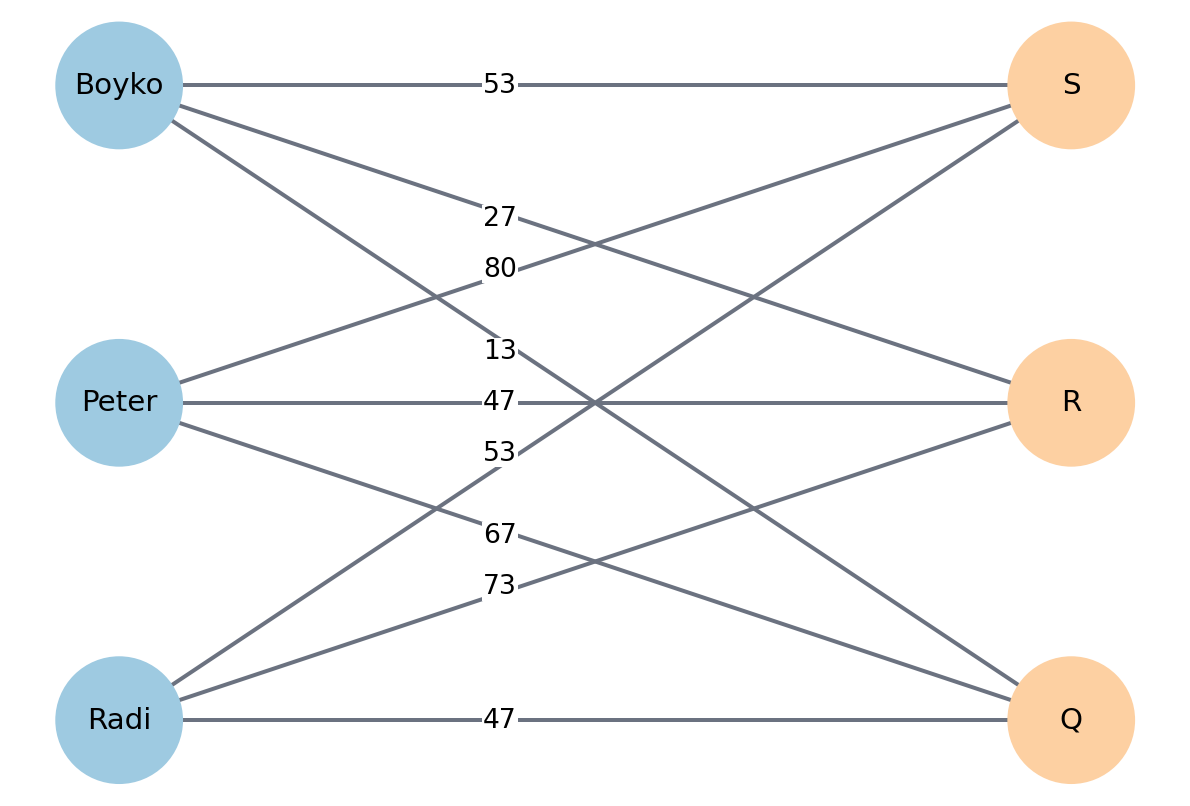

In [3]:
#| label: fig-graph-efficiency-scores
#| fig-cap: "Двуделен  (bipartite) граф на оценките за ефективност."

B = nx.Graph()

employees = dt.index.tolist()
tasks = dt.columns.tolist()

B.add_nodes_from(employees, bipartite=0)
B.add_nodes_from(tasks, bipartite=1)

for employee in employees:
    for task in tasks:
        B.add_edge(employee, task, weight=dt.loc[employee, task])

positions = {}
positions.update((employee, (0, index)) for index, employee in enumerate(employees[::-1]))
positions.update((task, (1.8, index)) for index, task in enumerate(tasks[::-1]))

plt.figure(figsize=(6, 4))
nx.draw(
    B,
    pos=positions,
    with_labels=True,
    node_color=['#9ecae1' if node in employees else '#fdd0a2' for node in B.nodes()],
    node_size=2200,
    edge_color='#6b7280',
    width=1.5,
    font_size=11
)

for employee_index, employee in enumerate(employees):
    for task_index, task in enumerate(tasks):
        x0, y0 = positions[employee]
        x1, y1 = positions[task]
        label_x = (x0 + x1) / 2 - 0.18
        label_y = (y0 + y1) / 2 + 0.08 * (employee_index - task_index)
        plt.text(label_x, label_y, str(dt.loc[employee, task]), fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=0.3))

# plt.title('Двуделен граф на оценките за ефективност')
plt.axis('off')
plt.show()

Нашата задача е да разпределим служителите така, че общата ефективност да е максимална.

- Формулирайте оптимизационен модел за тази задача.
- Решете модела в [Excel](./excel/Job-Allocation.xlsx) и сравнете решението си с резултата в @tbl-assignment-matrix-result.


:::{.callout-note collapse="true"}
## Решение

Всеки модел се състои от пет части:

1. Множества
2. Променливи
3. Параметри
4. Целева функция
5. Ограничения

В тази задача имаме две множества:

- Сътрудници: $M = \{\text{B}, \text{P}, \text{Ra}\}$
- Задачи: $P = \{\text{S}, \text{R}, \text{Q}\}$

Променливите на модела са бинарни (т.е. могат да приемат стойности 0 или 1):

$x_{ij} \in \{0, 1\}$: 1, ако сътрудник $i$ поеме подзадача $j$, и 0 в противен случай (т.е. бинарни променливи)

Параметрите тук са ефективностите на сътрудниците в различните подзадачи:

$e_{ij}$: ефективност на сътрудник $i$ в подзадача $j$

Целевата функция е общата ефективност:

$\max \sum_{i \in M} \sum_{j \in P} e_{ij} \cdot x_{ij}$

Това е съкратен запис на:

$$
\begin{align*}
\max & \quad e_{\text{B}, \text{S}} \cdot x_{\text{B}, \text{S}} + e_{\text{B}, \text{R}} \cdot x_{\text{B}, \text{R}} + e_{\text{B}, \text{Q}} \cdot x_{\text{B}, \text{Q}} \\
& + e_{\text{P}, \text{S}} \cdot x_{\text{P}, \text{S}} + e_{\text{P}, \text{R}} \cdot x_{\text{P}, \text{R}} + e_{\text{P}, \text{Q}} \cdot x_{\text{P}, \text{Q}} \\
& + e_{\text{Ra}, \text{S}} \cdot x_{\text{Ra}, \text{S}} + e_{\text{Ra}, \text{R}} \cdot x_{\text{Ra}, \ text{R}} + e_{\ text{Ra}, \ text{Q}} \cdot x_{\ text{Ra}, \text{Q}}
\end{align*}
$$

Ограниченията са:

1. Всеки сътрудник трябва да поеме точно една подзадача:

$\sum_{j \in P} x_{ij} = 1 \quad \forall i \in M$

Това е съкратен запис на:

$$
\begin{align*}
i = \text{B} & \quad \Rightarrow \quad x_{\text{B}, \text{S}} + x_{\text{B}, \text{R}} + x_{\text{B}, \text{Q}} = 1 \\
i = \text{P} & \quad \Rightarrow \quad x_{\text{P}, \text{S}} + x_{\text{P}, \text{R}} + x_{\text{P}, \text{Q}} = 1 \\
i = \text{Ra} & \quad \Rightarrow \quad x_{\text{Ra}, \text{S}} + x_{\text{Ra}, \text{R}} + x_{\text{Ra}, \text{Q}} = 1 \\
\end{align*}
$$

2. Всяка подзадача трябва да бъде поета от точно един сътрудник:

$$
\sum_{i \in M} x_{ij} = 1 \quad \forall j \in P
$$

Това е съкратен запис на:

$$
\begin{align*}
j = \text{S} & \quad \Rightarrow \quad x_{\text{B}, \text{S}} + x_{\text{P}, \text{S}} + x_{\text{Ra}, \text{S}} = 1 \\
j = \text{R} & \quad \Rightarrow \quad x_{\text{B}, \text{R}} + x_{\text{P}, \text{R}} + x_{\text{Ra}, \text{R}} = 1 \\
j = \text{Q} & \quad \Rightarrow \quad x_{\text{B}, \text{Q}} + x_{\text{P}, \text{Q}} + x_{\text{Ra}, \text{Q}} = 1 \\
\end{align*}
$$

:::


In [4]:

m = gp.Model('Разпределение на задачи')
m.setParam('LogToConsole', 0)

# Променливите x_{ij} показват дали задача j е възложена на служител i

x = m.addVars(dt.index, dt.columns, vtype=GRB.BINARY, name='assign')

# Целевата функция е сумата от произведенията на ефективностите и назначенията

m.setObjective(gp.quicksum(dt.loc[i, j] * x[i, j] for i in dt.index for j in dt.columns), GRB.MAXIMIZE)

# Всеки служител може да получи точно една задача

m.addConstrs((x.sum(i, '*') == 1 for i in dt.index), 'Сътрудник')

# Всяка задача може да бъде възложена на точно един служител

m.addConstrs((x.sum('*', j) == 1 for j in dt.columns), 'Задача')

m.optimize()

# Решението като pandas DataFrame

solution = pd.DataFrame(
    ((i, j, x[i, j].x) for i in dt.index for j in dt.columns),
    columns=['Сътрудник', 'Задача', 'Назначение']
)

Restricted license - for non-production use only - expires 2027-11-29


Set parameter LogToConsole to value 0


In [5]:
#| label: tbl-assignment-matrix-result
#| tbl-cap: "Матрица на назначенията (1 - назначение, 0 - без назначение)."

assignment_matrix = (
    solution.pivot(index='Сътрудник', columns='Задача', values='Назначение')
    .reindex(index=dt.index, columns=dt.columns)
    .astype(int)
)

assignment_matrix

,S,R,Q
Boyko,1,0,0
Peter,0,0,1
Radi,0,1,0


In [6]:
# m.write("__Job-Allocation.lp")

# with open("__Job-Allocation.lp", 'r') as file:
#     print(file.read())